### Import

In [2]:
# 기본 라이브러리
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import matplotlib.gridspec as gridspec
sns.set()

from tqdm import tqdm 
import yfinance as yf
import time
from tvDatafeed import TvDatafeed, Interval

# 직접 구현 패키지
from CustomHMM import CustomHMM
from HmmStockData import hmm_stock_data
from HmmStockData import cal_historical_mdd
from HmmStockData import show_price_by_regime

In [3]:
# 트레이딩뷰 객체 생성
tv = TvDatafeed()
time.sleep(1)
save_vols_ohlcv = {}
# 트레이딩뷰 객체에 전달할 변동성지수 티커와 거래소 딕셔너리 
# 야후 파이낸스 데이터 로드 실패 지수
tv_vol_symbol_exchange_dict = {
    'VKOSPI' : ['VOLATILITY', 'KRX'], # VKOSPI

}

# 변동성지수 및 거래소 정보를 활용한 TradingView DataLoad 시도
for idx_name, sym_exc in tqdm(tv_vol_symbol_exchange_dict.items()) :
    
    # 하나의 변동성 지수 별로 총 5번의 Data 탐색을 시도
    for i in range(10) :
        
        # 티커 정보, 거래소 정보 분리  
        symbol,exchange = sym_exc[0], sym_exc[1] 
        
        try : 
            # 변동성 지수 데이터 추출 시도
            df = tv.get_hist(symbol=symbol, exchange=exchange, interval=Interval.in_daily, n_bars=10000)

            # 데이터가 정상적으로 Load된 경우 -> 딕셔너리 저장
            if df is not None and not df.empty:
                
                # 야후 파이낸스에서 받은 형식으로 통일
                df.drop(columns=['symbol', 'volume'], inplace=True)
                df.index = pd.to_datetime(df.index).strftime('%Y-%m-%d')
                df.index.name = 'Date'
                df.columns.name = idx_name
                df.rename(columns={'open' : 'Open', 'low' : 'Low', 'close' : 'Close', 'high' : 'High'}, inplace=True)
                df = df[['Close', 'Open', 'Low', 'High']]
                
                save_vols_ohlcv[idx_name] = df
                print(f'{idx_name} - {i+1}번 시도 성공')
                break
            
            # 데이터를 불러오지 못한 경우 : 1초 SKIP 
            else :
                time.sleep(1) 
                print(f'{idx_name} - {i+1}번 시도 실패')
                continue
        except :
            print(f'{idx_name} - {i+1}번 호출 중 문제 발생')

you are using nologin method, data you access may be limited
  0%|          | 0/1 [00:00<?, ?it/s]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol


VKOSPI - 1번 시도 실패


100%|██████████| 1/1 [00:11<00:00, 11.48s/it]

VKOSPI - 2번 시도 성공


In [101]:
# HMM 분석 대상 티커
ticker = '^KS11'  

# 훈련 기간 지정 -> 테스트 기간 자동 지정
train_start = '2013-02-04'
train_end = '2023-12-30'

# Lookback
vol_p = 3
sr_p = 3

# Train / Test 가격 데이터 및 훈련 데이터 다운로드
close_train, train_data, close_test, test_data = hmm_stock_data(ticker, train_start, train_end, market = 'index', scale = False, vol_period=vol_p, sr_period=sr_p)

vkospi = pd.DataFrame(save_vols_ohlcv['VKOSPI']['Close']).rename(columns = {'Close' : 'VKOSPI'})
train_iv = vkospi.loc['2013-02-05' : '2025-12-29']
test_iv = vkospi.loc['2026-01-06' : '2026-05-08']

# 1. 인덱스를 datetime 타입으로 변환 (문자열인 경우 대비)
train_data.index = pd.to_datetime(train_data.index)
train_iv.index = pd.to_datetime(train_iv.index)
close_train.index = pd.to_datetime(close_train.index)

# 2. 시간 정보를 제거하고 '날짜'만 남기기 (병합 정확도 향상)
train_data.index = train_data.index.normalize()
train_iv.index = train_iv.index.normalize()
close_train.index = close_train.index.normalize()

# 3. 인덱스 기준으로 수평 병합 (이미지에서의 NaN 문제 해결)
train_df = pd.concat([train_data, train_iv, close_train], axis=1).dropna()

# 1. 인덱스를 datetime 타입으로 변환 (문자열인 경우 대비)
test_data.index = pd.to_datetime(test_data.index)
test_iv.index = pd.to_datetime(test_iv.index)
close_test.index = pd.to_datetime(close_test.index)

# 2. 시간 정보를 제거하고 '날짜'만 남기기 (병합 정확도 향상)
test_data.index = test_data.index.normalize()
test_iv.index = test_iv.index.normalize()
close_test.index = close_test.index.normalize()

# 3. 인덱스 기준으로 수평 병합 (이미지에서의 NaN 문제 해결)
test_df = pd.concat([test_data, test_iv, close_test], axis=1).dropna()

# 데이터 분리 
train_data = train_df[['rets', f'{vol_p}m_vol', f'{sr_p}m_sr', 'VKOSPI']]
test_data = test_df[['rets', f'{vol_p}m_vol', f'{sr_p}m_sr', 'VKOSPI']]
close_train = pd.DataFrame(train_df['price'])
close_test = pd.DataFrame(test_df['price'])

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

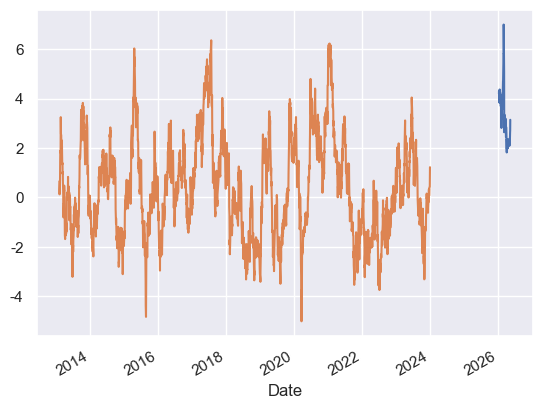

In [102]:
test_data[f'{sr_p}m_sr'].plot()
train_data[f'{sr_p}m_sr'].plot()

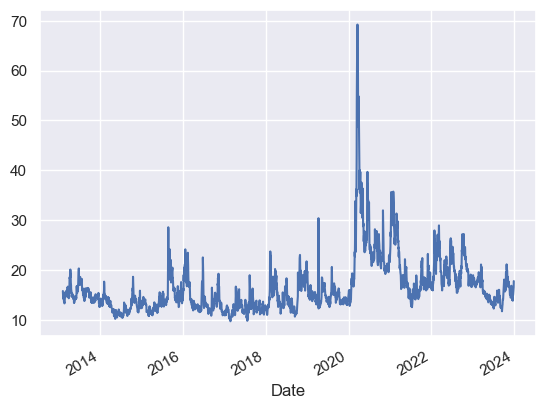

<Axes: xlabel='Date'>

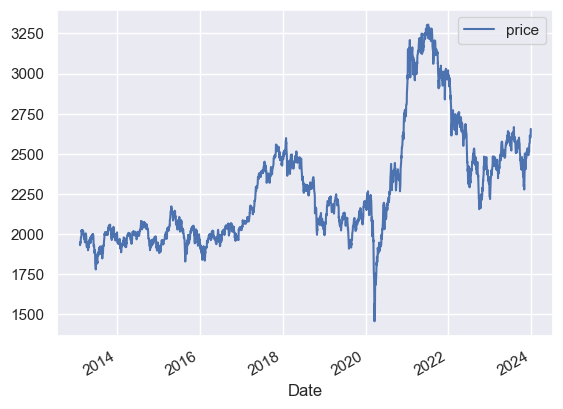

In [103]:
train_data['VKOSPI'].plot()
plt.show()

close_train.plot()

### Custom Multivariate Gaussian HMM Initialize and fit

- 객체 선언과 동시에 학습 시작
- 학습이 완료된 객체 대하여 학습된 과정을 `show_ll_history` 메서드로 시각화
- 학습된 Multivariate Gaussain HMM Parameter Set 추출 (단순 확인용)

EM Iteration [ max iter 200 ]:   4%|▍         | 8/200 [00:04<01:47,  1.79it/s]

Iteration 8: Convergence reached. (Log-Likelyhood : 3902.83)


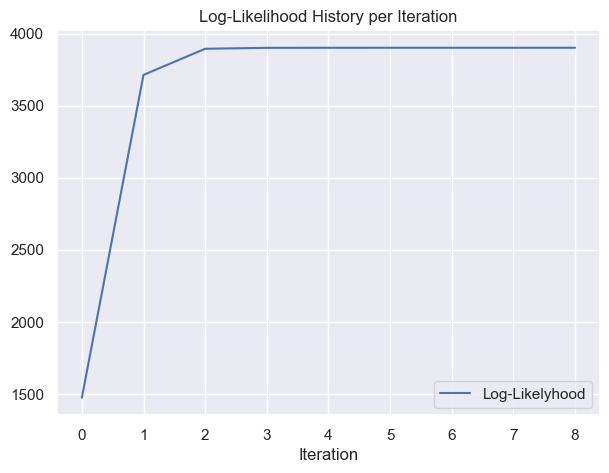

In [104]:
# 상태 개수
k = 3

# 객체 생성 동시에 학습
hmm = CustomHMM(train_data, k, max_iter=200) 

# Log-Likelyhood 최적화 과정 시각화 
hmm.show_ll_history() 

# 학습된 파라미터 추출
Pi, A, mus, covs = [hmm.Pi, hmm.A, hmm.mus, hmm.covs]

### 변수 별 상태 별 정규분포 플랏 시각화

In [105]:
state_anlaysis = {0 : [], 1 : [], 2 : []}

# 샤프비율 성과에 따른 구분
variable_select_num = 2
for i, rank_num in enumerate(pd.Series(hmm.mus[:,variable_select_num]).rank(ascending=False).values) :
    if rank_num == 1 :
        state_anlaysis[i].append('High Ret')
        
    elif rank_num == 2 :
        state_anlaysis[i].append('Mid Ret')
    elif rank_num == 3 :
        state_anlaysis[i].append('Low Ret')

# 변동성에 따른 구분
variable_select_num = 3
for i, rank_num in enumerate(pd.Series(hmm.mus[:,variable_select_num]).rank(ascending=False).values) :
    if rank_num == 1 :
        state_anlaysis[i].append('High Vol')
    elif rank_num == 2 :
        state_anlaysis[i].append('Mid Vol')
    elif rank_num == 3 :
        state_anlaysis[i].append('Low Vol')

In [106]:
state_anlaysis

{0: ['Low Ret', 'Mid Vol'],
 1: ['Mid Ret', 'Low Vol'],
 2: ['High Ret', 'High Vol']}

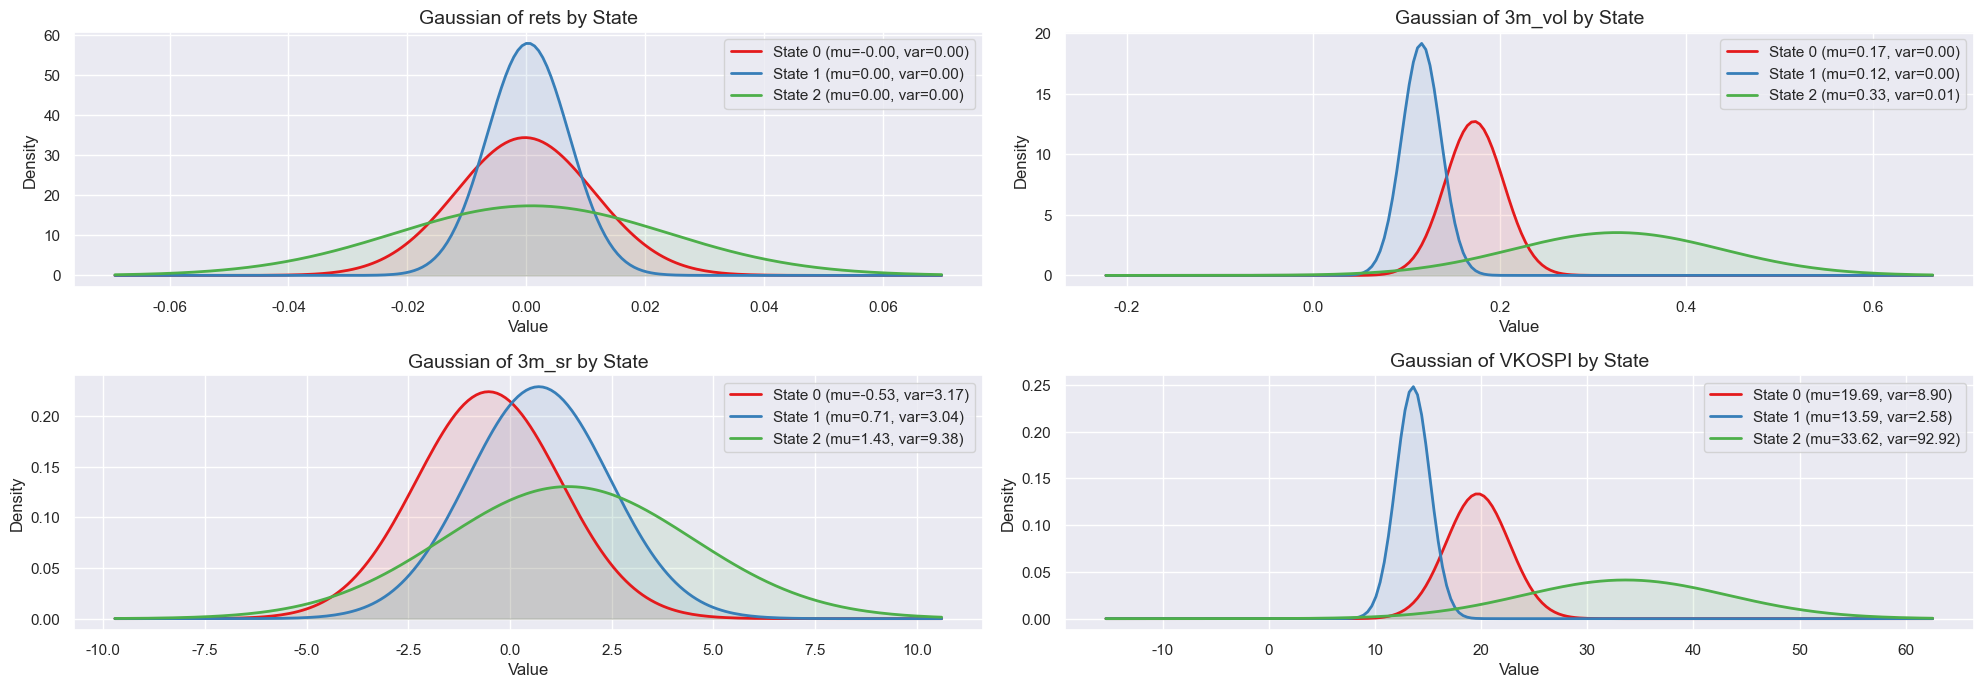

In [107]:
hmm.show_gaussian()

### HMM($\Lambda^*$) 와 Train / Test Data 가 주어졌을 때, Scaled Forward / Backward Log-Likelyhood 확인 

In [108]:
# Train : Forward / Backward
train_alpha_unscaled, train_alpha_scaled, train_forward_likelyhood = hmm.forward(train_data)
train_beta_unscaled, train_beta_scaled, train_backward_likelyhood = hmm.backward(train_data)

# Test : Forward / Backward
test_alpha_unscaled, test_alpha_scaled, test_forward_likelyhood = hmm.forward(test_data)
test_beta_unscaled, test_beta_scaled, test_backward_likelyhood = hmm.backward(test_data)

# Trian : Likelyhood 값 일치 여부 확인
print(f'Train : Forward / Backward Likelyhood 일치 여부 : {np.allclose(train_forward_likelyhood, train_backward_likelyhood)}')

# Test : Likelyhood 값 일치 여부 확인
print(f'Test: Forward / Backward Likelyhood 일치 여부 : {np.allclose(test_forward_likelyhood, test_backward_likelyhood)}')

Train : Forward / Backward Likelyhood 일치 여부 : True
Test: Forward / Backward Likelyhood 일치 여부 : True


### HMM($\Lambda^*$) 와 Train / Test Data 가 주어졌을 때, Viterbi 최적 상태 전이 경로와 종가 가격 매칭 시각화

- Viterbi Algorithm은 기본적으로 주어진 기간의 데이터를 모두 본 후, Backtracking 으로 최적의 경로를 결정하므로 실시간 투자 판단에 활용할 수 없음.

- 단지, HMM($\Lambda^*$)가 Market의 Color를 잘 구분했는지 확인하는 용도

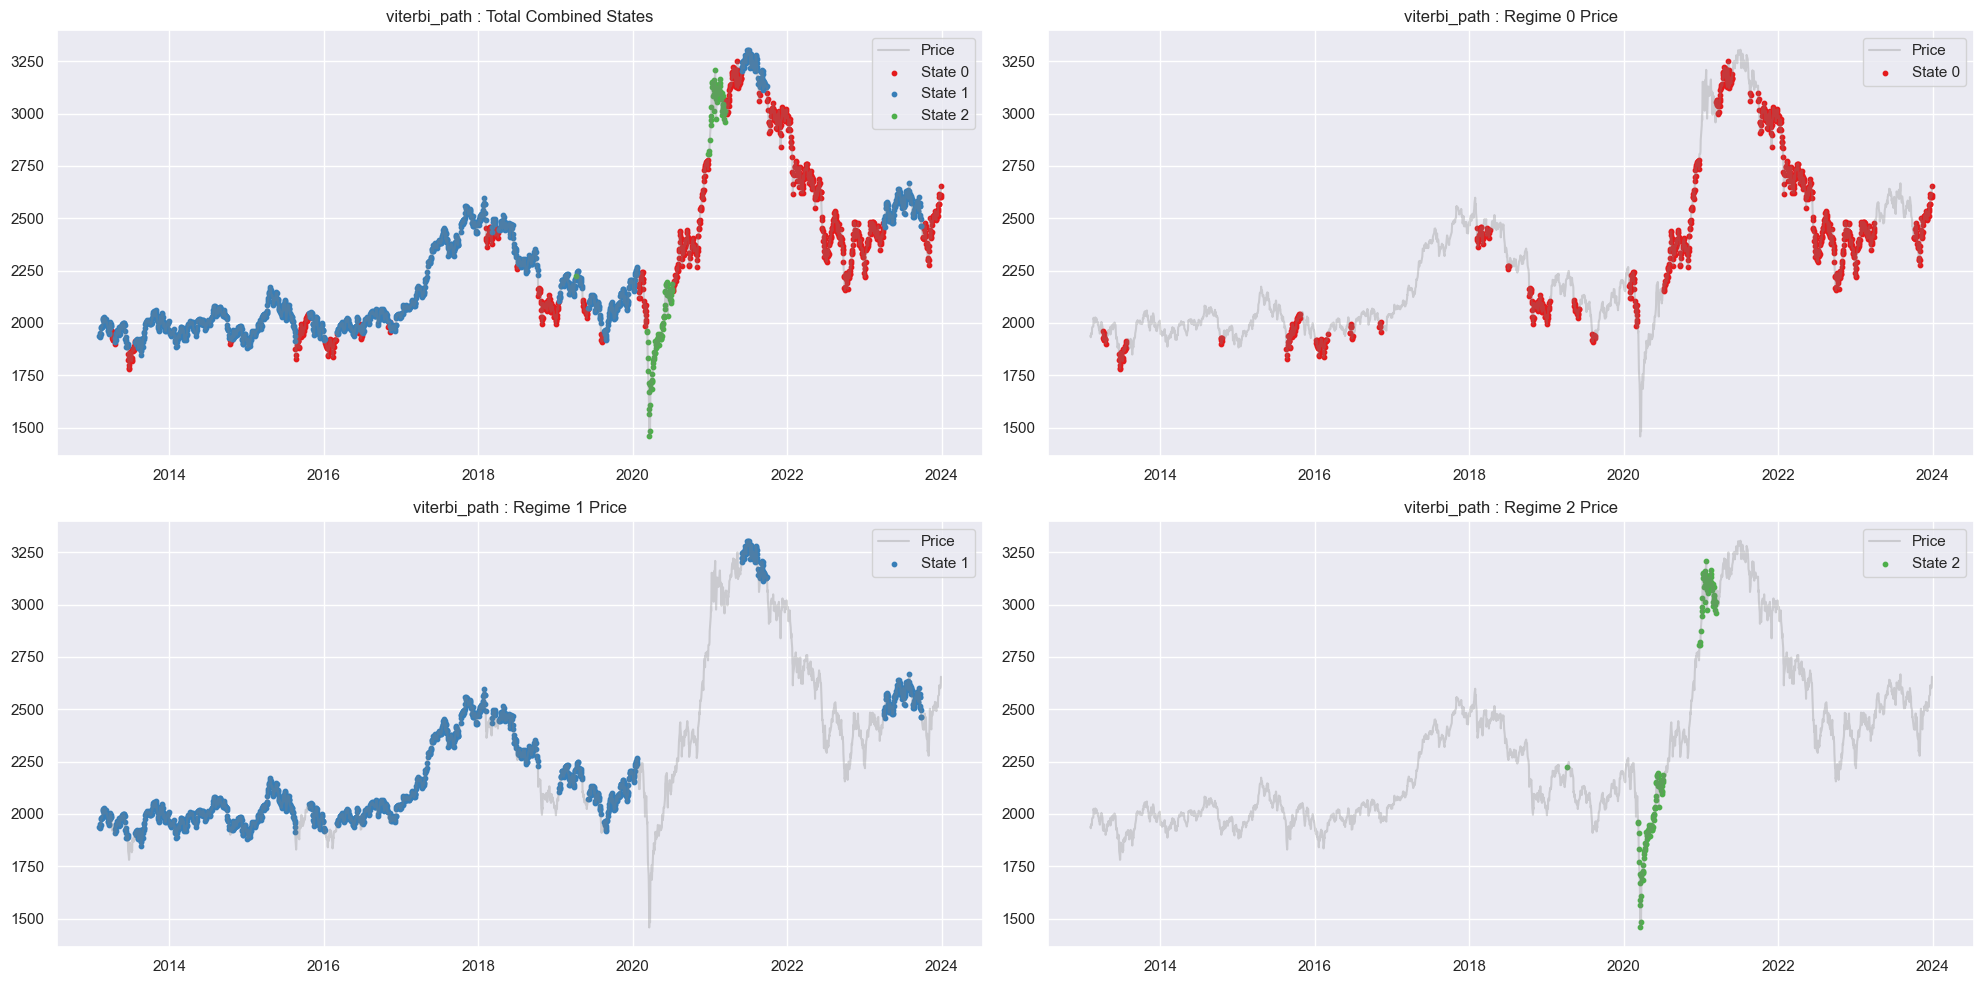

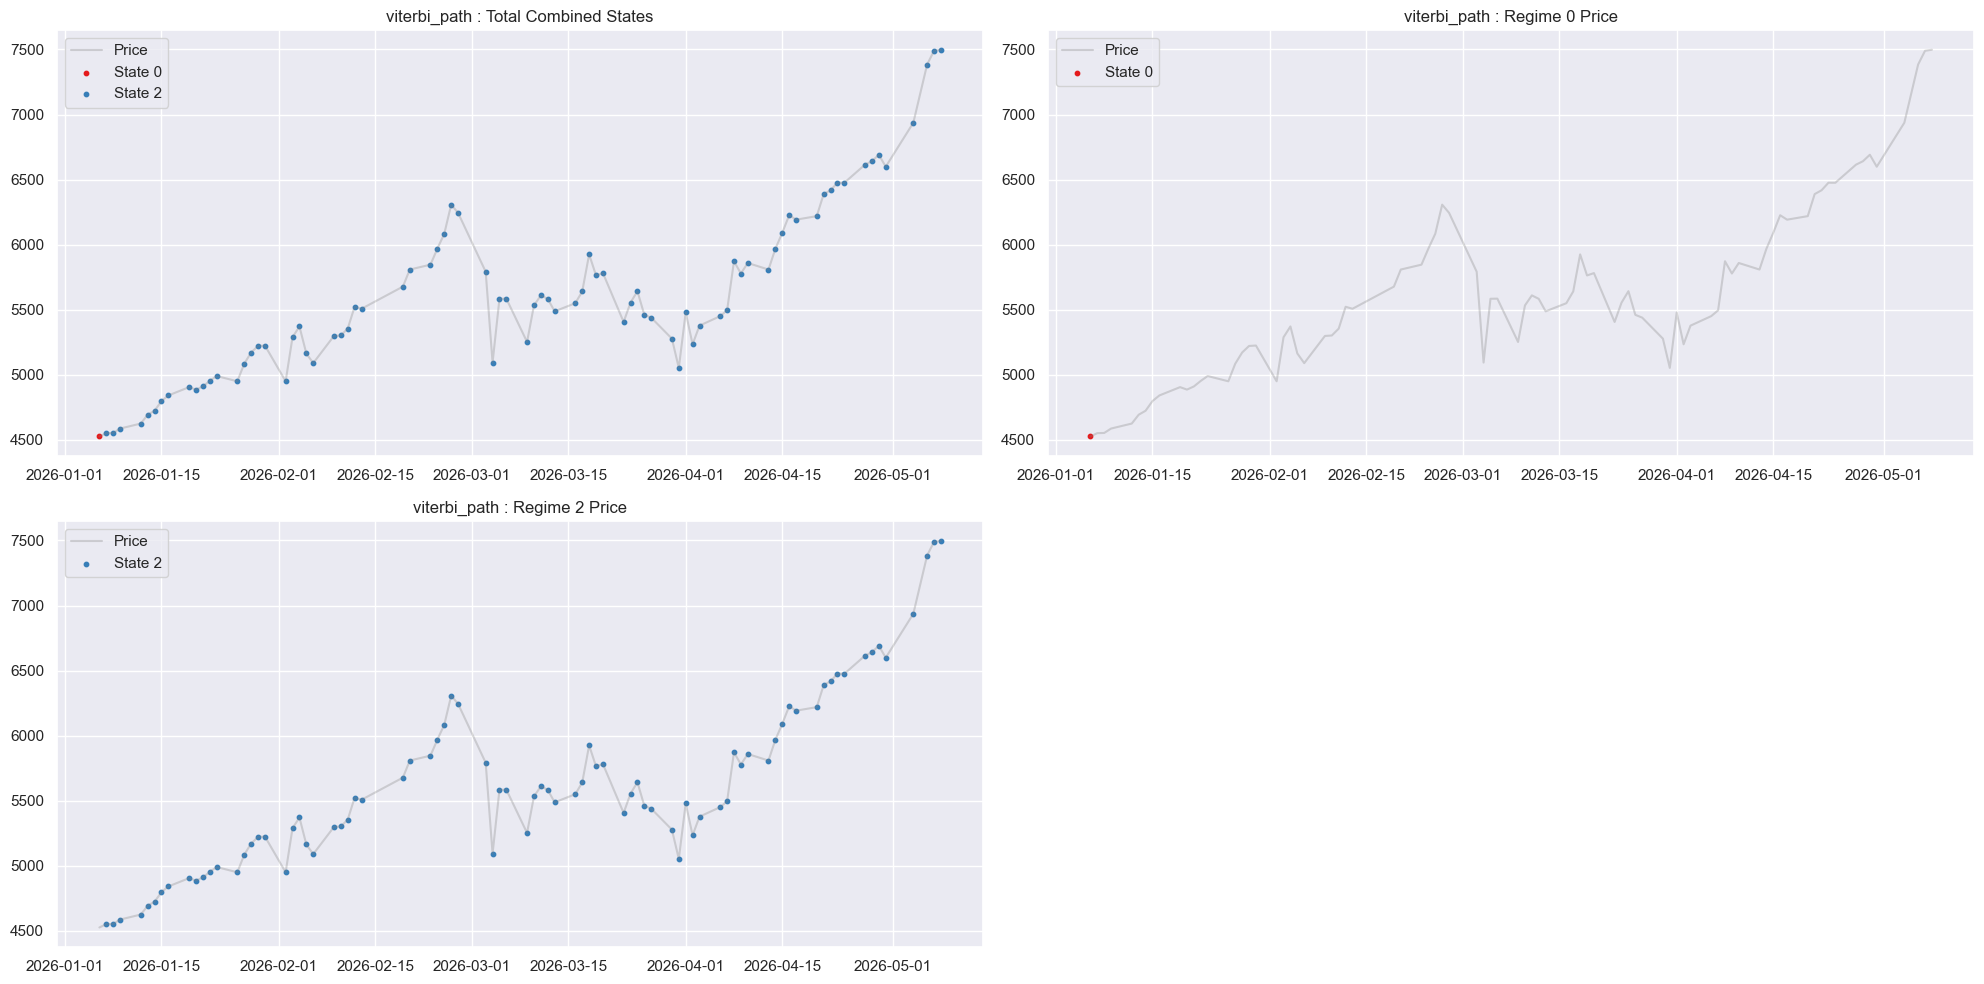

In [109]:
# Train Data 의 Viterbi 최적 상태 전이 경로 매칭 시각화
viterbi_close_train = close_train.copy()
train_viterbi, train_viterbi_path = hmm.viterbi(train_data)
viterbi_close_train['viterbi_path'] = train_viterbi_path
show_price_by_regime(viterbi_close_train, 'viterbi_path') 

# Test Data 의 Viterbi 최적 상태 전이 경로 매칭 시각화
viterbi_close_test = close_test.copy()
test_viterbi, test_viterbi_path = hmm.viterbi(test_data)
viterbi_close_test['viterbi_path'] = test_viterbi_path 
show_price_by_regime(viterbi_close_test, 'viterbi_path')

### HMM($\Lambda^*$) 와 Train / Test Data 가 주어졌을 때, Smoothing으로 구한 최적의 상태 전이 경로와 종가 가격 매칭 시각화

- Smoothing Algorithm은 기본적으로 주어진 기간의 데이터를 모두 본 후, Backtracking 으로 최적의 경로를 결정하므로 실시간 투자 판단에 활용할 수 없음.

- 단지, HMM($\Lambda^*$)가 Market의 Color를 잘 구분했는지 확인하는 용도

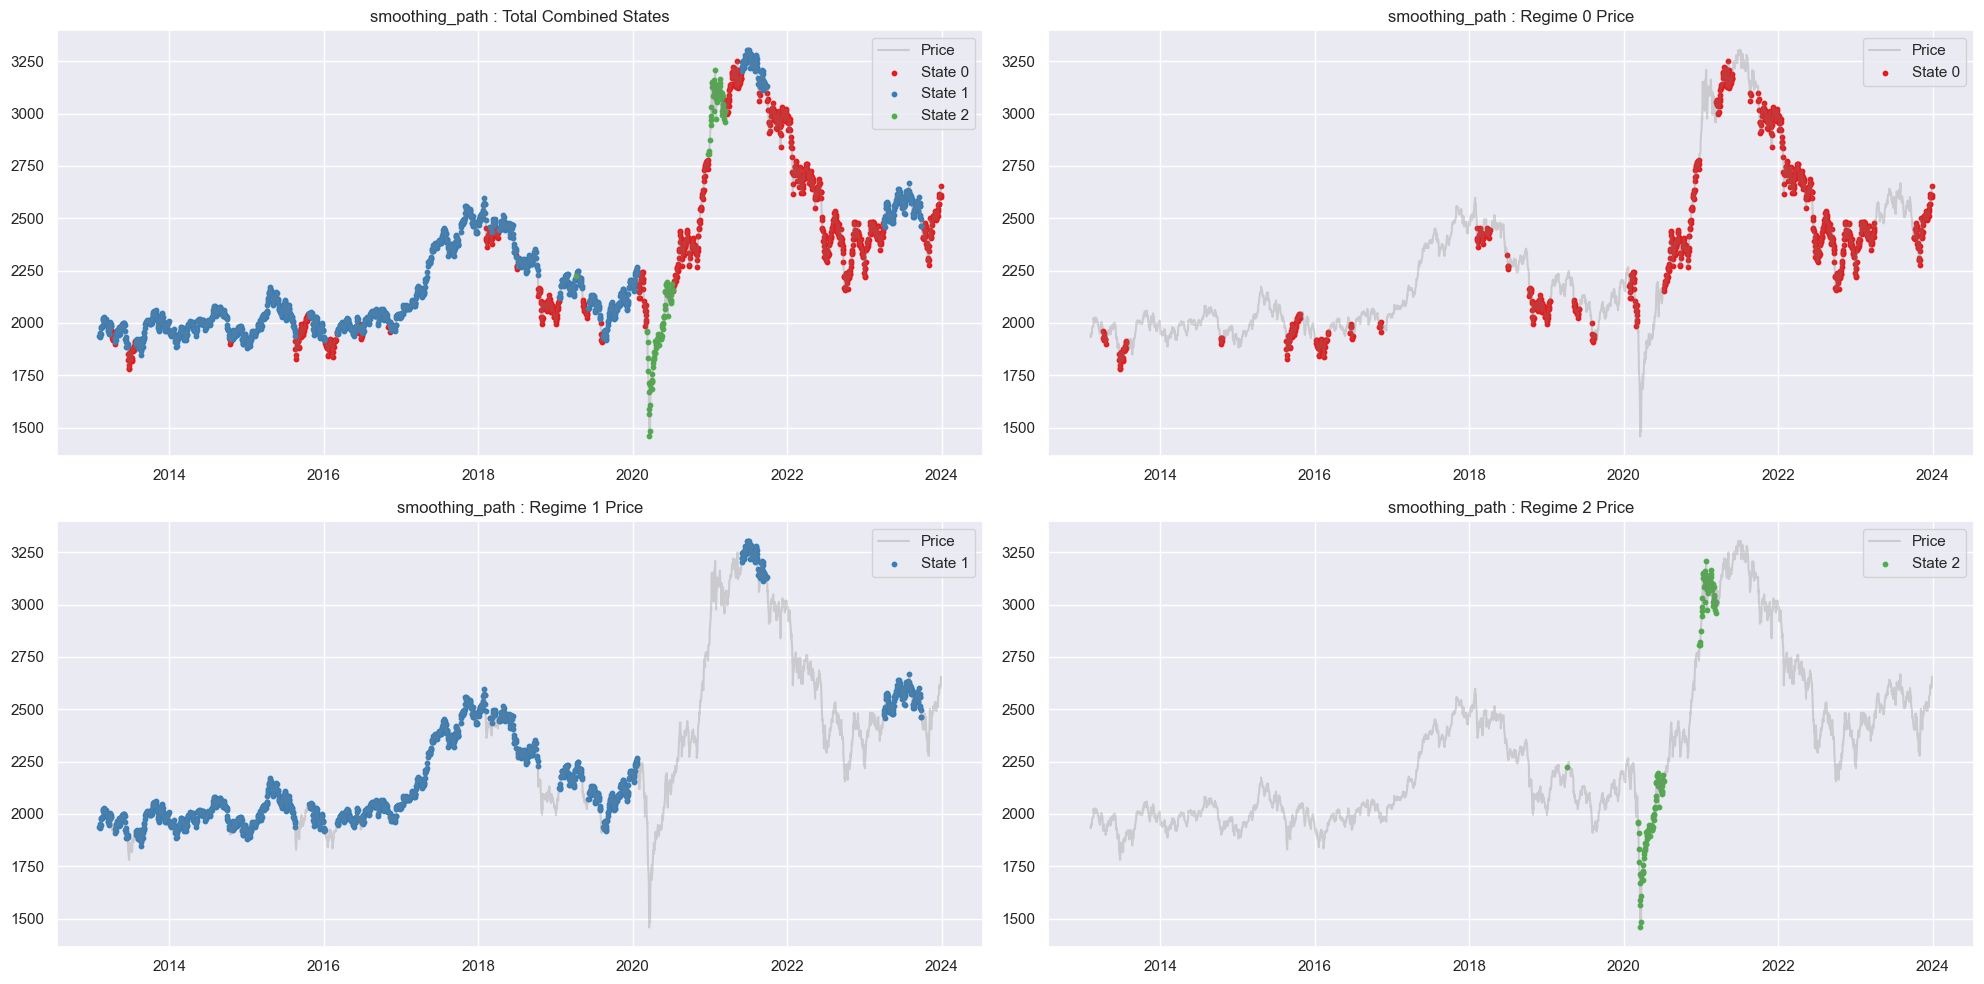

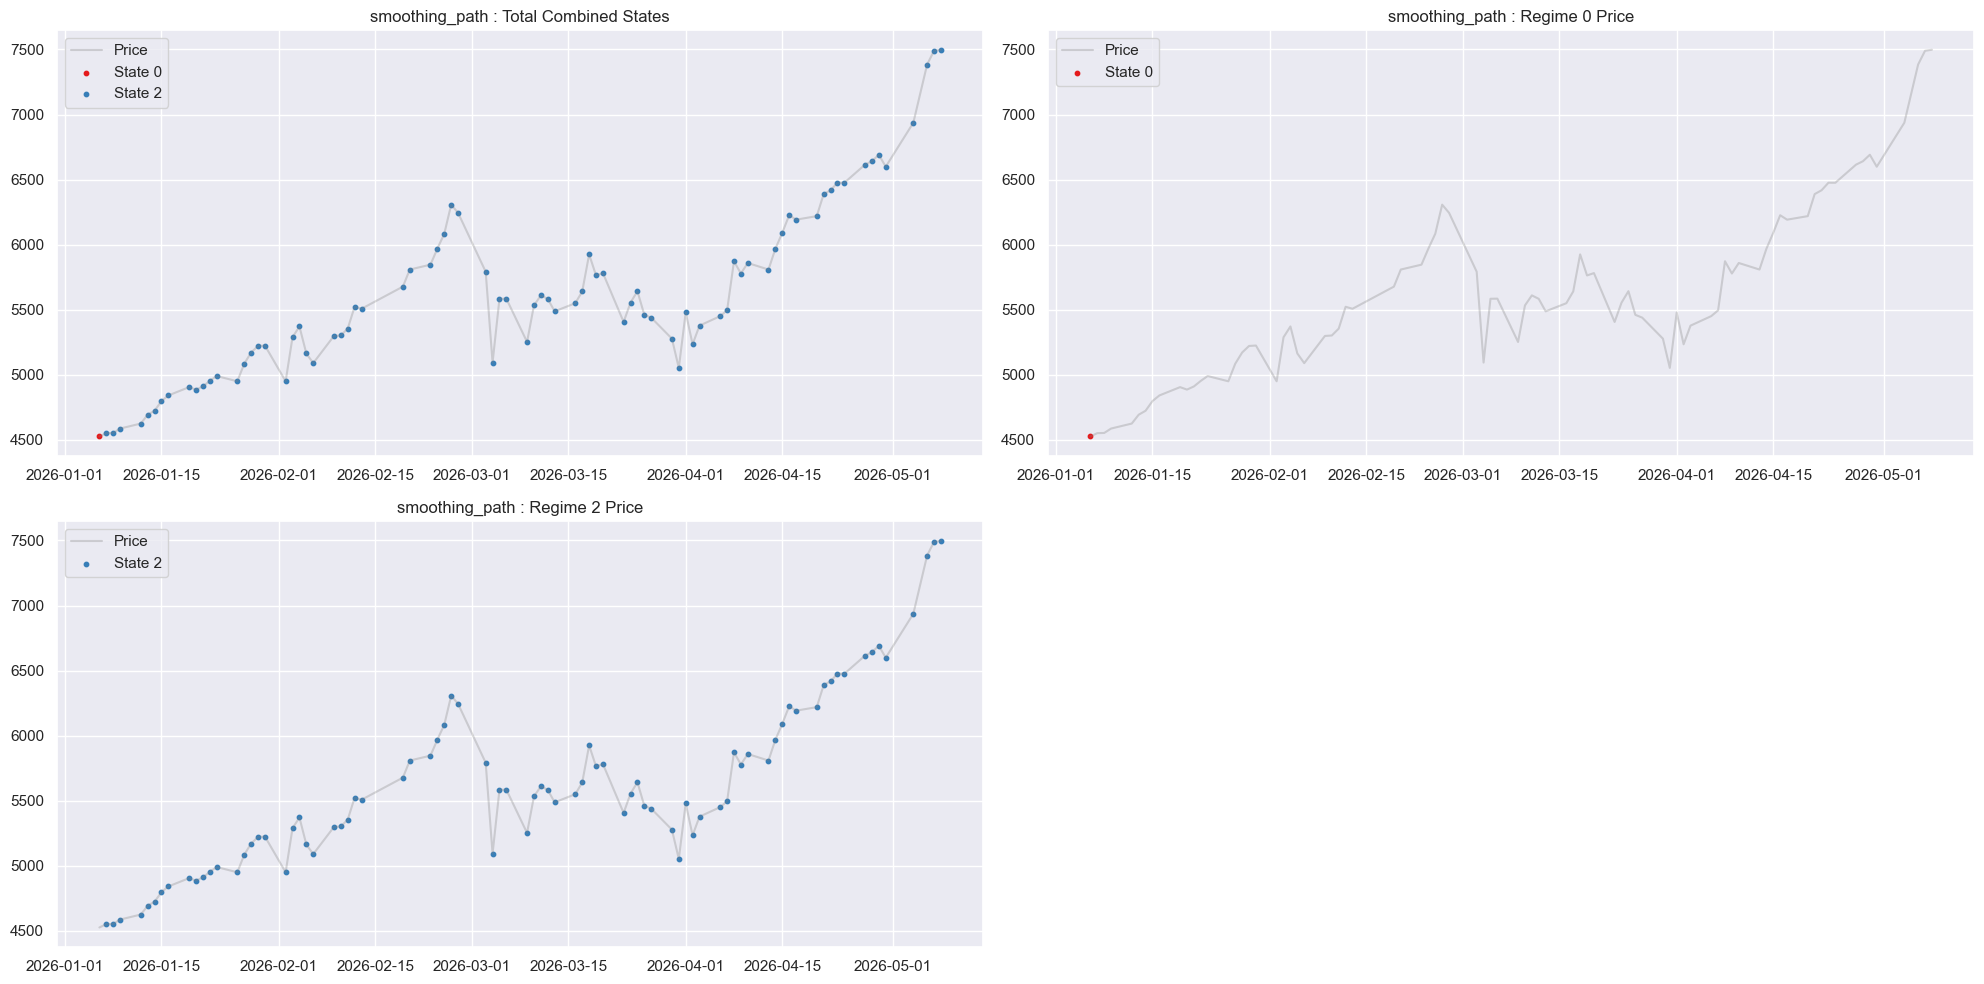

In [110]:
# Train Data 의 smoothing 기반 최적 상태 전이 경로 매칭 시각화
smoothing_close_train = close_train.copy()
train_f, train_fpath = hmm.smoothing(train_data)
smoothing_close_train['smoothing_path'] = train_fpath
show_price_by_regime(smoothing_close_train, 'smoothing_path') 

# Test Data 의 smoothing 기반 최적 상태 전이 경로 매칭 시각화
smoothing_close_test = close_test.copy()
test_f, test_fpath = hmm.smoothing(test_data)
smoothing_close_test['smoothing_path'] = test_fpath 
show_price_by_regime(smoothing_close_test, 'smoothing_path')

### HMM($\Lambda^*$) 와 Train / Test Data 가 주어졌을 때, Filtering으로 구한 최적의 상태 전이 경로와 종가 가격 매칭 시각화

- Filtering Algorithm은 현 시점의 관측값을 보고 나면 즉각적으로 Market의 Color를 판단할 수 있으므로 HMM을 활용한 실시간 가중치 조절에 있어서 핵심이 되는 알고리즘 
- 오늘의 관측값을 보고 내일의 투자 가중치를 결정할 수 있음. 

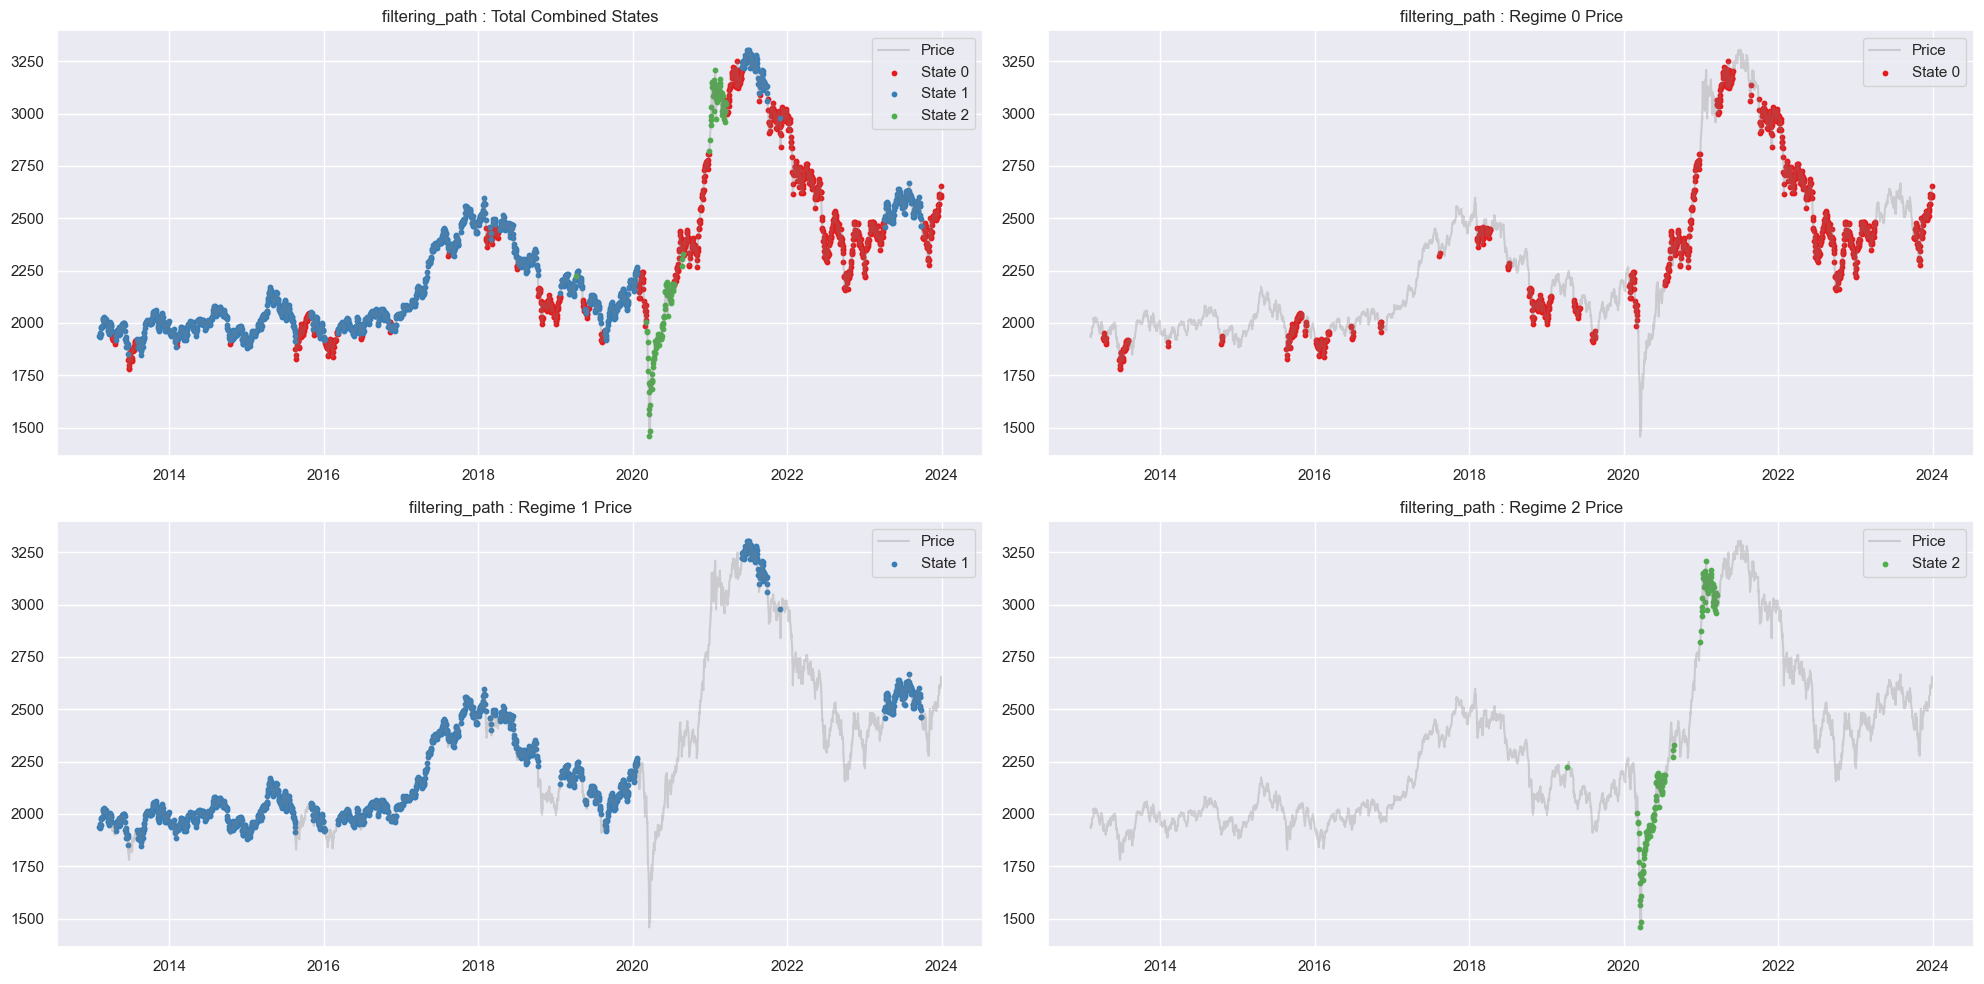

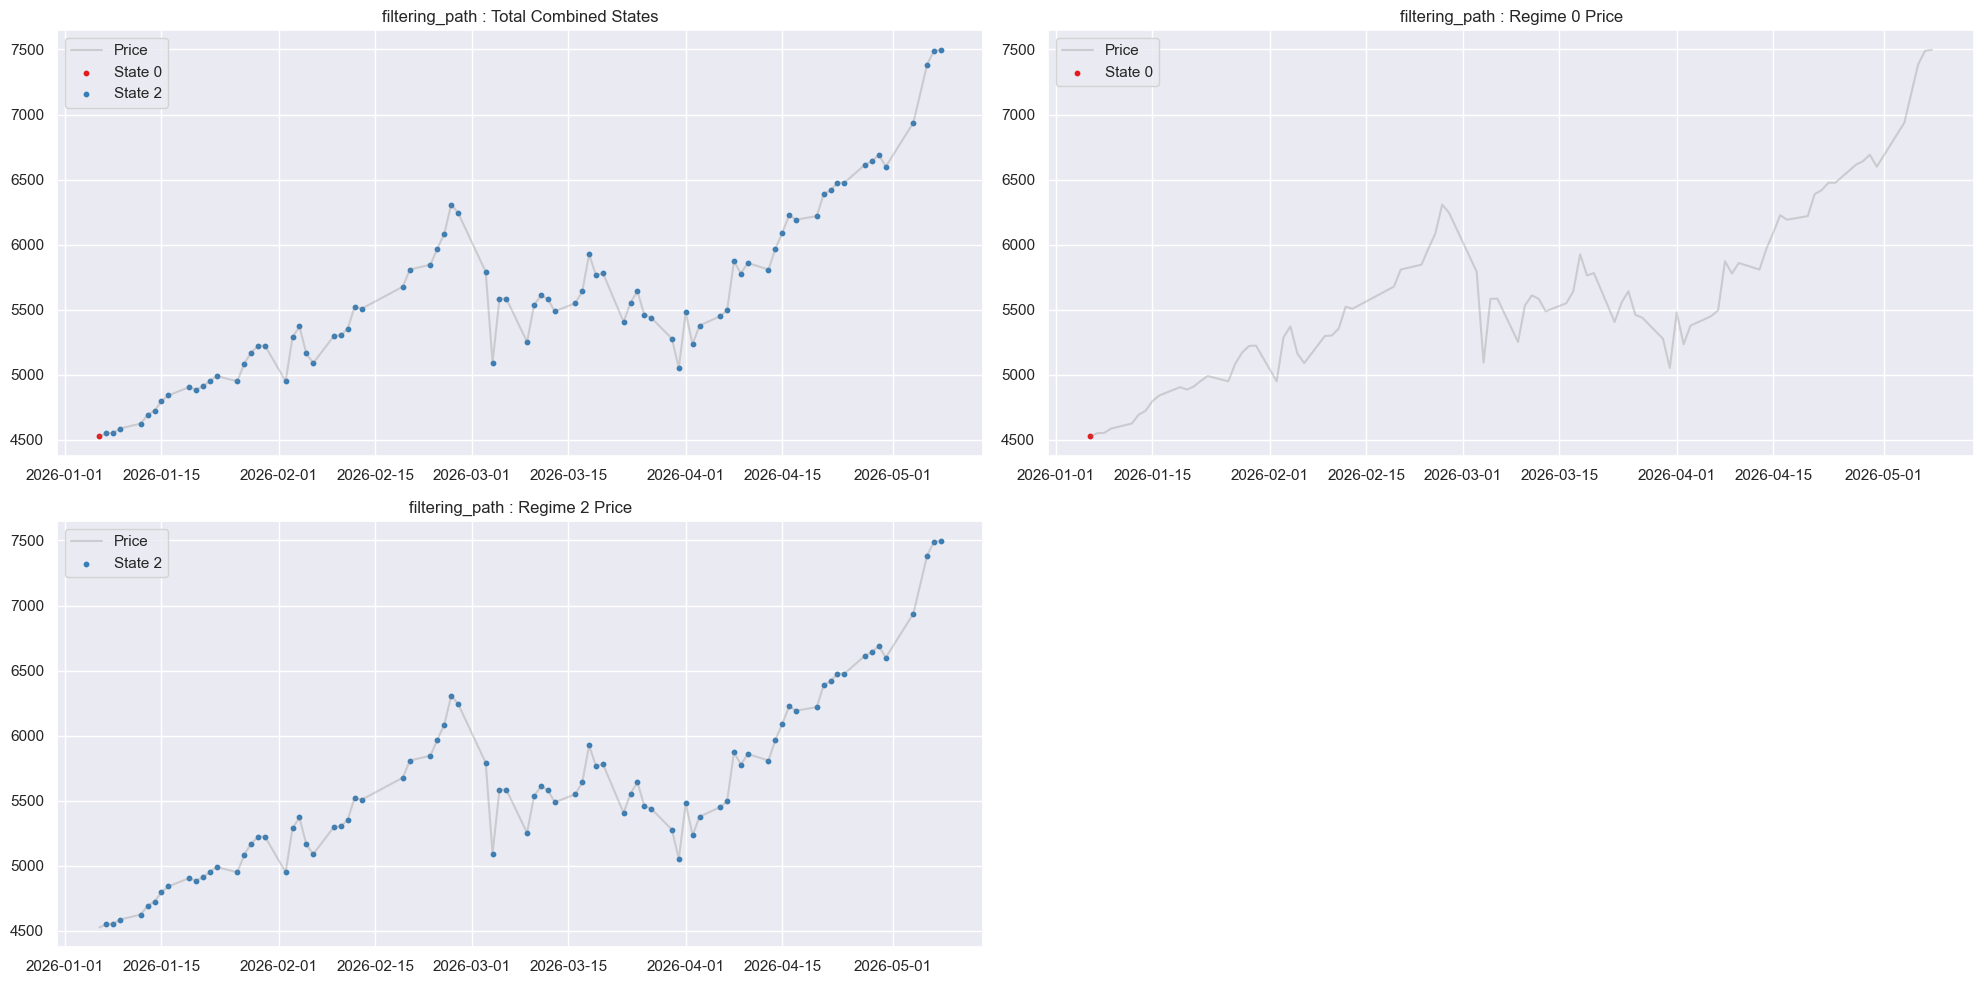

In [111]:
# Train Data 의 Filtering 기반 최적 상태 전이 경로 매칭 시각화
filtering_close_train = close_train.copy()
train_f, train_fpath = hmm.filtering(train_data)
filtering_close_train['filtering_path'] = train_fpath
show_price_by_regime(filtering_close_train, 'filtering_path') 

# Test Data 의 Filtering 기반 최적 상태 전이 경로 매칭 시각화
filtering_close_test = close_test.copy()
test_f, test_fpath = hmm.filtering(test_data)
filtering_close_test['filtering_path'] = test_fpath 
show_price_by_regime(filtering_close_test, 'filtering_path')

In [112]:
filtering_close_train

,price,filtering_path
Date,,
2013-02-05,1938.180054,1
2013-02-06,1936.189941,1
2013-02-07,1931.770020,1
2013-02-08,1950.900024,1
2013-02-12,1945.790039,1
...,...,...
2023-12-21,2600.020020,0
2023-12-22,2599.510010,0
2023-12-26,2602.590088,0


### HMM($\Lambda^*$) 와 Train / Test Data 가 주어졌을 때, Prediction으로 구한 최적의 상태 전이 경로와 종가 가격 매칭 시각화

- Prediction 또한 현 시점의 관측값을 보고 나면 즉각적으로 h 시점 이후의 Market의 Color를 예측할 수 있으므로 HMM을 활용한 실시간 가중치 조절에 있어서 핵심이 되는 알고리즘 
- 오늘의 관측값을 보고 내일의 Regime을 예측하여 가중치 부여에 대한 신뢰도를 측정. 

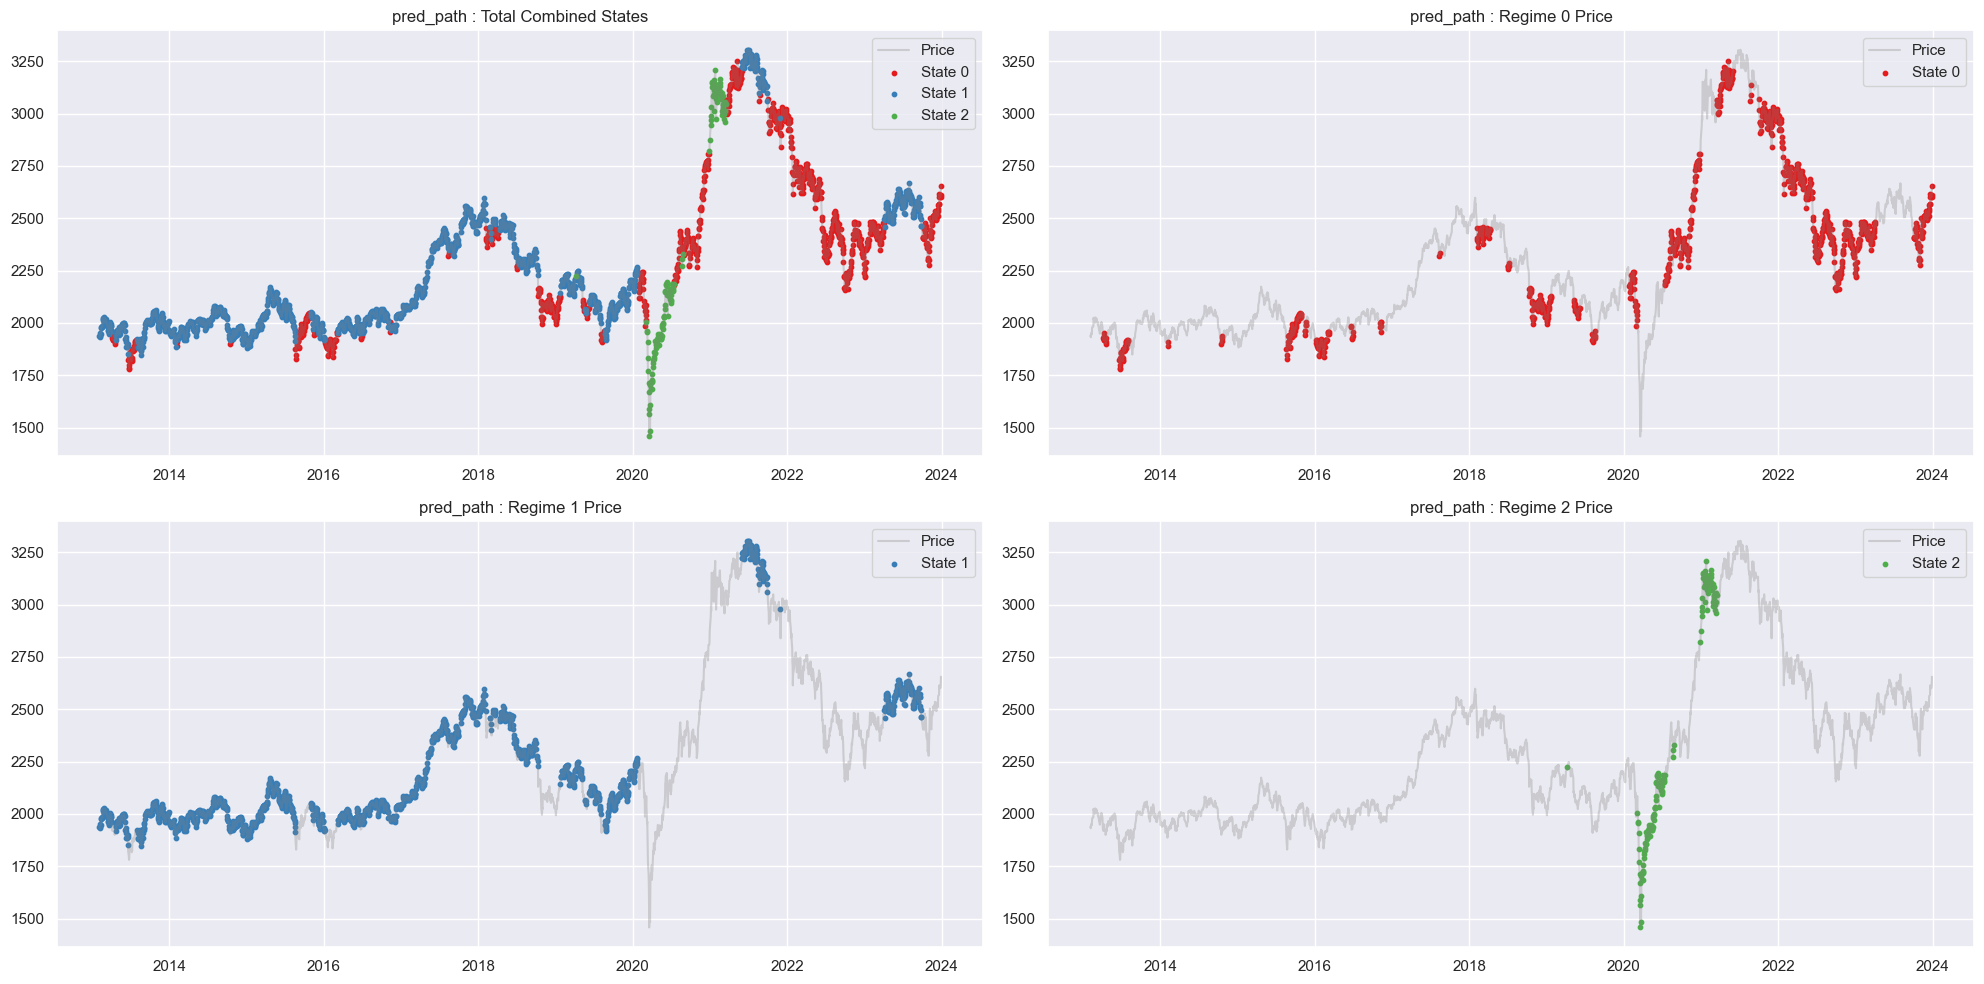

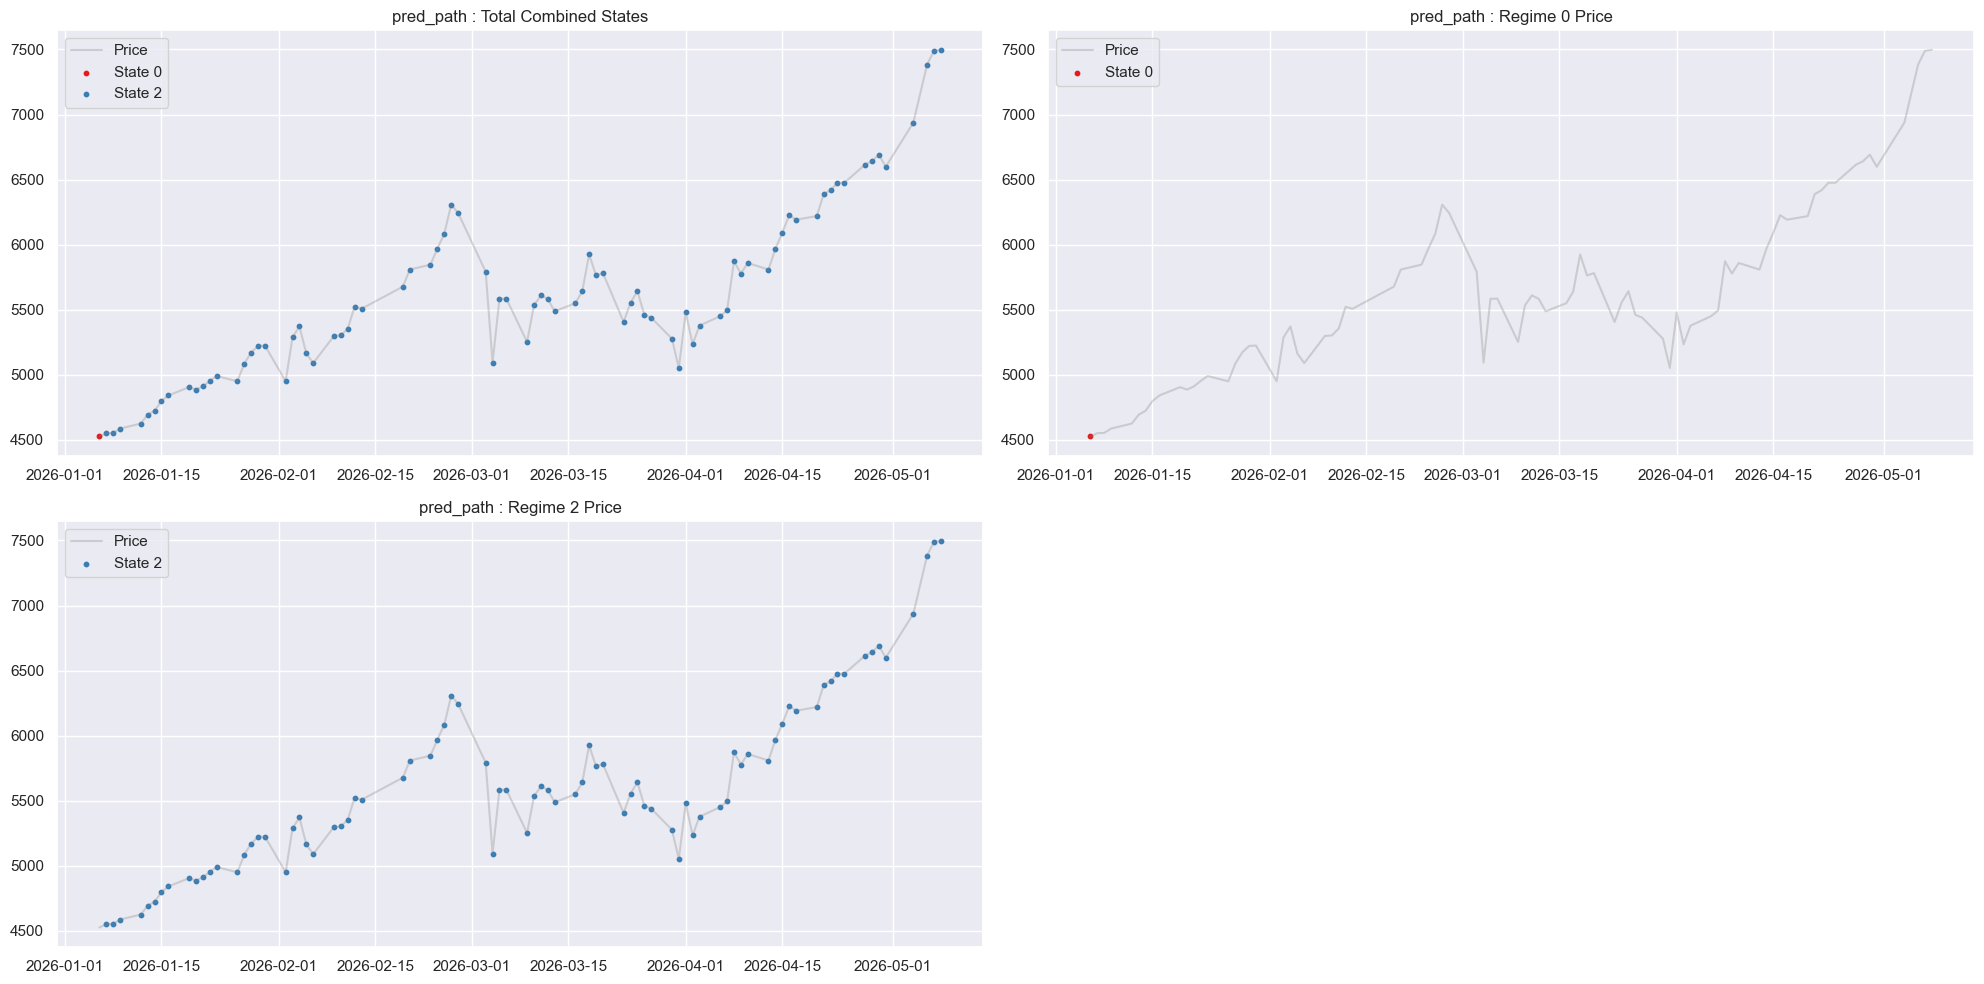

In [113]:
# Train Data 의 Filtering 기반 최적 상태 전이 경로 매칭 시각화
prediction_close_train = close_train.copy()
train_pred, train_pred_path = hmm.predict_state(train_data, h = 2)
prediction_close_train['pred_path'] = train_pred_path
show_price_by_regime(prediction_close_train, 'pred_path') 

# Test Data 의 Filtering 기반 최적 상태 전이 경로 매칭 시각화

prediction_close_test = close_test.copy()
test_pred, test_pred_path = hmm.filtering(test_data)
prediction_close_test['pred_path'] = test_pred_path 
show_price_by_regime(prediction_close_test, 'pred_path')

### Test Data에 대해서 Filtering 에 따른 최적 경로 종가 매칭 시각화 및 그 때의 필터링 확률 시각화 

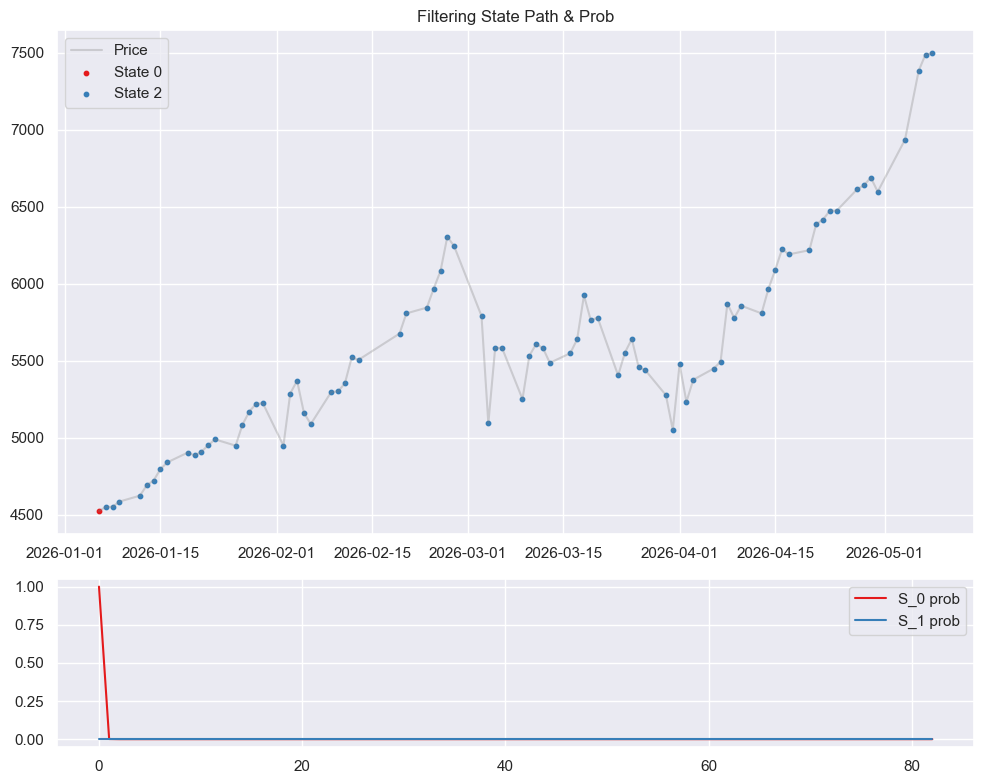

In [114]:
hmm.filtering_path_prob(test_data, close_test)